# Stroke Prediction Pipeline

This notebook implements the pipeline described in the paper you uploaded (preprocessing, EM-like imputation, RUS undersampling, DNN/ANN/CNN, transfer-learning placeholder, 4 proposed models, stacking ensemble, visualizations, and saving encoders/scalers/models). Update file paths at the top before running.

In [1]:
# Cell 1 - Imports and constants
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import warnings
warnings.filterwarnings('ignore')

# Paths (change if needed)

STROKE_CSV = os.path.join( "data.csv")       # Put your stroke CSV here
      # Optional surgical pretrain dataset
OUTPUT_DIR = "./saved_models"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
print('Ready. Update STROKE_CSV if needed and run cells in order.')

Ready. Update STROKE_CSV if needed and run cells in order.


In [2]:
# Cell 2 - Load dataset
if not os.path.exists(STROKE_CSV):
    raise FileNotFoundError(f"Stroke CSV not found at {STROKE_CSV}. Please place the file there or change STROKE_CSV.")
df = pd.read_csv(STROKE_CSV)
print("Original shape:", df.shape)
df.head()

Original shape: (43400, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0


In [3]:
# Cell 3 - Quick EDA & cleaning
print(df.info())
print('\nMissing values per column:')
print(df.isnull().sum())

# Drop ID column if present
for possible_id in ['id', 'Id', 'ID']:
    if possible_id in df.columns:
        df = df.drop(columns=[possible_id])
        print("Dropped ID column:", possible_id)
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  object 
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  object 
 6   work_type          43400 non-null  object 
 7   Residence_type     43400 non-null  object 
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                41938 non-null  float64
 10  smoking_status     30108 non-null  object 
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 4.0+ MB
None

Missing values per column:
id                       0
gender                   0
age                      0
hypertension             0
heart_disease   

(43400, 11)

In [4]:
# Cell 4 - Identify numeric vs categorical features
# Set target column name - change if different
target_col = 'stroke'
if target_col not in df.columns:
    # try common alternatives
    for t in ['target', 'Stroke', 'stroke_status', 'stroke_detected']:
        if t in df.columns:
            target_col = t
            break
print('Using target column:', target_col)

features = [c for c in df.columns if c != target_col]
num_cols = df[features].select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = [c for c in features if c not in num_cols]
print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Using target column: stroke
Numeric columns: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
Categorical columns: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [5]:
# Cell 5 - Imputation (IterativeImputer ~ EM-like for numeric; fill categorical)
num_imputer = IterativeImputer(random_state=RANDOM_STATE)
if len(num_cols) > 0:
    df[num_cols] = num_imputer.fit_transform(df[num_cols])
    joblib.dump(num_imputer, os.path.join(OUTPUT_DIR, "iterative_imputer.joblib"))
    print('Saved iterative imputer.')
else:
    print('No numeric columns to impute.')

for c in cat_cols:
    df[c] = df[c].fillna('unknown')
print('Imputation done.')

Saved iterative imputer.
Imputation done.


In [6]:
# Cell 6 - Label encode categorical variables and save encoders
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c].astype(str))
    encoders[c] = le
    joblib.dump(le, os.path.join(OUTPUT_DIR, f"le_{c}.joblib"))
print('Saved label encoders for categorical columns.')

Saved label encoders for categorical columns.


In [7]:
# Cell 7 - Scaling (MinMax)
scaler = MinMaxScaler()
if len(num_cols) > 0:
    df[num_cols] = scaler.fit_transform(df[num_cols])
joblib.dump(scaler, os.path.join(OUTPUT_DIR, 'minmax_scaler.joblib'))
print('Saved MinMax scaler.')

Saved MinMax scaler.


In [8]:
# Cell 8 - Undersampling to 1:1 using RandomUnderSampler
X = df[features].values
y = df[target_col].astype(int).values
print('Original class distribution:', dict(zip(*np.unique(y, return_counts=True))))
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_res, y_res = rus.fit_resample(X, y)
print('After RUS distribution:', dict(zip(*np.unique(y_res, return_counts=True))))
joblib.dump(rus, os.path.join(OUTPUT_DIR, 'random_undersampler.joblib'))

Original class distribution: {0: 42617, 1: 783}
After RUS distribution: {0: 783, 1: 783}


['./saved_models\\random_undersampler.joblib']

In [9]:
# Cell 8 - Oversampling to 1:1 using SMOTE
from imblearn.over_sampling import SMOTE

X = df[features].values
y = df[target_col].astype(int).values

print('Original class distribution:', dict(zip(*np.unique(y, return_counts=True))))

smote = SMOTE(random_state=RANDOM_STATE)
X_res, y_res = smote.fit_resample(X, y)

print('After SMOTE distribution:', dict(zip(*np.unique(y_res, return_counts=True))))

joblib.dump(smote, os.path.join(OUTPUT_DIR, 'smote_oversampler.joblib'))


Original class distribution: {0: 42617, 1: 783}
After SMOTE distribution: {0: 42617, 1: 42617}


['./saved_models\\smote_oversampler.joblib']

In [10]:
# Cell 9 - Train/test split 80:20
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=RANDOM_STATE, stratify=y_res)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (68187, 10) Test: (17047, 10)


In [11]:
# Cell 10 - Utility functions for metrics and plotting
def compute_metrics(y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = None
    if y_prob is not None:
        try:
            auc = roc_auc_score(y_true, y_prob)
        except:
            auc = None
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    gmean = np.sqrt(recall * (tn / (tn+fp + 1e-9)))
    fnr = fn / (tp + fn + 1e-9)
    fpr = fp / (tn + fp + 1e-9)
    return dict(acc=acc, precision=prec, recall=recall, f1=f1, auc=auc, gmean=gmean, fnr=fnr, fpr=fpr)

def plot_conf_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(title)
    plt.show()

In [12]:
# Cell 11 - Build and train DNN
def build_dnn(input_shape, hidden_units=[128,64], lr=1e-3):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_shape,)))
    for u in hidden_units:
        model.add(layers.Dense(u, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(0.2))
    model.add(layers.Dense(1, activation='sigmoid'))
    opt = optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

dnn = build_dnn(X_train.shape[1], hidden_units=[128,64], lr=1e-3)
es = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
history_dnn = dnn.fit(X_train, y_train, validation_split=0.1, epochs=60, batch_size=32, callbacks=[es], verbose=1)
y_prob_dnn = dnn.predict(X_test).ravel()
y_pred_dnn = (y_prob_dnn >= 0.5).astype(int)
metrics_dnn = compute_metrics(y_test, y_pred_dnn, y_prob_dnn)
print('DNN metrics:', metrics_dnn)
dnn.save(os.path.join(OUTPUT_DIR, 'dnn_model.h5'))

Epoch 1/60
1918/1918 [==============================] - 24s 5ms/step - loss: 0.4786 - accuracy: 0.7751 - val_loss: 0.4343 - val_accuracy: 0.8067
Epoch 2/60
1918/1918 [==============================] - 9s 5ms/step - loss: 0.4438 - accuracy: 0.7932 - val_loss: 0.4195 - val_accuracy: 0.8102
Epoch 3/60
1918/1918 [==============================] - 9s 5ms/step - loss: 0.4322 - accuracy: 0.7998 - val_loss: 0.4073 - val_accuracy: 0.8164
Epoch 4/60
1918/1918 [==============================] - 9s 5ms/step - loss: 0.4249 - accuracy: 0.8063 - val_loss: 0.4008 - val_accuracy: 0.8204
Epoch 5/60
1918/1918 [==============================] - 9s 5ms/step - loss: 0.4165 - accuracy: 0.8103 - val_loss: 0.3891 - val_accuracy: 0.8278
Epoch 6/60
1918/1918 [==============================] - 9s 5ms/step - loss: 0.4075 - accuracy: 0.8152 - val_loss: 0.3803 - val_accuracy: 0.8322
Epoch 7/60
1918/1918 [==============================] - 10s 5ms/step - loss: 0.4031 - accuracy: 0.8190 - val_loss: 0.3787 - val_accurac

In [14]:
# Cell 12 - ANN (shallow)
def build_ann(input_shape, hidden_units=[64,32], lr=1e-3):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_shape,)))
    for u in hidden_units:
        model.add(layers.Dense(u, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model

ann = build_ann(X_train.shape[1], hidden_units=[64,32])
history_ann = ann.fit(X_train, y_train, validation_split=0.1, epochs=50, batch_size=32, callbacks=[es], verbose=1)
y_prob_ann = ann.predict(X_test).ravel()
y_pred_ann = (y_prob_ann >= 0.5).astype(int)
metrics_ann = compute_metrics(y_test, y_pred_ann, y_prob_ann)
print('ANN metrics:', metrics_ann)
ann.save(os.path.join(OUTPUT_DIR, 'ann_model.h5'))

Epoch 1/50
36/36 [==============================] - 1s 8ms/step - loss: 0.6741 - accuracy: 0.5897 - val_loss: 0.6620 - val_accuracy: 0.6111
Epoch 2/50
36/36 [==============================] - 0s 3ms/step - loss: 0.6227 - accuracy: 0.6412 - val_loss: 0.6489 - val_accuracy: 0.6429
Epoch 3/50
36/36 [==============================] - 0s 3ms/step - loss: 0.5992 - accuracy: 0.6696 - val_loss: 0.6414 - val_accuracy: 0.6270
Epoch 4/50
36/36 [==============================] - 0s 3ms/step - loss: 0.5786 - accuracy: 0.6829 - val_loss: 0.6258 - val_accuracy: 0.6508
Epoch 5/50
36/36 [==============================] - 0s 3ms/step - loss: 0.5611 - accuracy: 0.6989 - val_loss: 0.6240 - val_accuracy: 0.6429
Epoch 6/50
36/36 [==============================] - 0s 3ms/step - loss: 0.5458 - accuracy: 0.7202 - val_loss: 0.6156 - val_accuracy: 0.6429
Epoch 7/50
36/36 [==============================] - 0s 3ms/step - loss: 0.5317 - accuracy: 0.7362 - val_loss: 0.6128 - val_accuracy: 0.6825
Epoch 8/50
36/36 [==

In [15]:
# Cell 13 - CNN for tabular (1D conv)
X_train_c = X_train.reshape((-1, X_train.shape[1], 1))
X_test_c  = X_test.reshape((-1, X_test.shape[1], 1))

def build_cnn_tabular(input_shape, lr=1e-3):
    inp = layers.Input(shape=(input_shape,1))
    x = layers.Conv1D(64, kernel_size=3, activation='relu')(inp)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inp, x)
    model.compile(optimizer=optimizers.Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn = build_cnn_tabular(X_train.shape[1], lr=1e-3)
history_cnn = cnn.fit(X_train_c, y_train, validation_split=0.1, epochs=40, batch_size=32, callbacks=[es], verbose=1)
y_prob_cnn = cnn.predict(X_test_c).ravel()
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)
metrics_cnn = compute_metrics(y_test, y_pred_cnn, y_prob_cnn)
print('CNN metrics:', metrics_cnn)
cnn.save(os.path.join(OUTPUT_DIR, 'cnn_model.h5'))

Epoch 1/40
36/36 [==============================] - 1s 10ms/step - loss: 0.6906 - accuracy: 0.5062 - val_loss: 0.6839 - val_accuracy: 0.5714
Epoch 2/40
36/36 [==============================] - 0s 3ms/step - loss: 0.6726 - accuracy: 0.6119 - val_loss: 0.6717 - val_accuracy: 0.6032
Epoch 3/40
36/36 [==============================] - 0s 3ms/step - loss: 0.6571 - accuracy: 0.6208 - val_loss: 0.6636 - val_accuracy: 0.6111
Epoch 4/40
36/36 [==============================] - 0s 3ms/step - loss: 0.6430 - accuracy: 0.6306 - val_loss: 0.6677 - val_accuracy: 0.5476
Epoch 5/40
36/36 [==============================] - 0s 3ms/step - loss: 0.6343 - accuracy: 0.6234 - val_loss: 0.6616 - val_accuracy: 0.5873
Epoch 6/40
36/36 [==============================] - 0s 3ms/step - loss: 0.6258 - accuracy: 0.6385 - val_loss: 0.6570 - val_accuracy: 0.5952
Epoch 7/40
36/36 [==============================] - 0s 3ms/step - loss: 0.6198 - accuracy: 0.6430 - val_loss: 0.6564 - val_accuracy: 0.5952
Epoch 8/40
36/36 [=

In [16]:
# Cell 14 - Proposed models: RandomForest, XGBoost, LightGBM, CatBoost
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_prob_rf = rf.predict_proba(X_test)[:,1]
y_pred_rf = rf.predict(X_test)
metrics_rf = compute_metrics(y_test, y_pred_rf, y_prob_rf)
print('RF metrics:', metrics_rf)
joblib.dump(rf, os.path.join(OUTPUT_DIR, 'rf_model.joblib'))

xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)
xgb_clf.fit(X_train, y_train)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:,1]
y_pred_xgb = xgb_clf.predict(X_test)
metrics_xgb = compute_metrics(y_test, y_pred_xgb, y_prob_xgb)
print('XGB metrics:', metrics_xgb)
joblib.dump(xgb_clf, os.path.join(OUTPUT_DIR, 'xgb_model.joblib'))

lgb_clf = lgb.LGBMClassifier(random_state=RANDOM_STATE)
lgb_clf.fit(X_train, y_train)
y_prob_lgb = lgb_clf.predict_proba(X_test)[:,1]
y_pred_lgb = lgb_clf.predict(X_test)
metrics_lgb = compute_metrics(y_test, y_pred_lgb, y_prob_lgb)
print('LGBM metrics:', metrics_lgb)
joblib.dump(lgb_clf, os.path.join(OUTPUT_DIR, 'lgb_model.joblib'))

cat_clf = CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)
cat_clf.fit(X_train, y_train)
y_prob_cat = cat_clf.predict_proba(X_test)[:,1]
y_pred_cat = cat_clf.predict(X_test)
metrics_cat = compute_metrics(y_test, y_pred_cat, y_prob_cat)
print('CatBoost metrics:', metrics_cat)
cat_clf.save_model(os.path.join(OUTPUT_DIR, 'catboost_model.cbm'))

RF metrics: {'acc': 0.7101910828025477, 'precision': 0.7012195121951219, 'recall': 0.732484076433121, 'f1': 0.7165109034267911, 'auc': 0.8186133311696215, 'gmean': 0.7098411065330277, 'fnr': 0.26751592356517506, 'fpr': 0.3121019108260376}
XGB metrics: {'acc': 0.7070063694267515, 'precision': 0.7210884353741497, 'recall': 0.6751592356687898, 'f1': 0.6973684210526315, 'auc': 0.8042922633778247, 'gmean': 0.7062887274183424, 'fnr': 0.32484076432914116, 'fpr': 0.2611464968136233}
[LightGBM] [Info] Number of positive: 626, number of negative: 626
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001697 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 614
[LightGBM] [Info] Number of data points in the train set: 1252, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LGBM metrics: {'acc': 0

In [ ]:
# ==== Improved Stacking Ensemble (High Accuracy Version) ====

from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import lightgbm as lgb
import joblib
import os

# Compute class weights (optional but useful)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

# Base Models (Optimized)
estimators = [
    ('rf', RandomForestClassifier(
        n_estimators=400,
        class_weight='balanced',
        max_features='sqrt',
        random_state=RANDOM_STATE
    )),
    
    ('xgb', xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=RANDOM_STATE
    )),
    
    ('lgb', lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=50,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE
    )),
]

# Stronger Meta-Learner (instead of logistic regression)
meta_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    random_state=RANDOM_STATE
)

# Stacking Model
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    passthrough=True,
    cv=10,
    n_jobs=-1
)

# Train
stack.fit(X_train, y_train)

# Predict
y_prob_stack = stack.predict_proba(X_test)[:,1]
y_pred_stack = stack.predict(X_test)

# Evaluate
metrics_stack = compute_metrics(y_test, y_pred_stack, y_prob_stack)
print("📈 Improved Stacking Model Metrics:", metrics_stack)

# Save Model
joblib.dump(stack, os.path.join(OUTPUT_DIR, "improved_stacking_ensemble.joblib"))
print("Model saved successfully!")


In [17]:
# Cell 15 - Stacking ensemble (meta-learner: logistic regression)
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)),
    ('lgb', lgb.LGBMClassifier(random_state=RANDOM_STATE)),
]
stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), passthrough=True, cv=5)
stack.fit(X_train, y_train)
y_prob_stack = stack.predict_proba(X_test)[:,1]
y_pred_stack = stack.predict(X_test)
metrics_stack = compute_metrics(y_test, y_pred_stack, y_prob_stack)
print('Stacking metrics:', metrics_stack)
joblib.dump(stack, os.path.join(OUTPUT_DIR, 'stacking_ensemble.joblib'))

[LightGBM] [Info] Number of positive: 626, number of negative: 626
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000136 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 614
[LightGBM] [Info] Number of data points in the train set: 1252, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 501, number of negative: 500
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 611
[LightGBM] [Info] Number of data points in the train set: 1001, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500500 -> initscore=0.001998
[Light

['./saved_models\\stacking_ensemble.joblib']

In [18]:
# Cell 16 - Comparison table and plots
results = {
    'DNN': metrics_dnn,
    'ANN': metrics_ann,
    'CNN': metrics_cnn,
    'RF': metrics_rf,
    'XGB': metrics_xgb,
    'LGBM': metrics_lgb,
    'CatBoost': metrics_cat,
    'Stack': metrics_stack
}

# Build DataFrame
rows = []
for name, m in results.items():
    rows.append({
        'model': name,
        'accuracy': m['acc'],
        'precision': m['precision'],
        'recall': m['recall'],
        'f1': m['f1'],
        'auc': m['auc'],
        'gmean': m['gmean'],
        'fnr': m['fnr'],
        'fpr': m['fpr']
    })
res_df = pd.DataFrame(rows).sort_values('accuracy', ascending=False).reset_index(drop=True)
res_df.style.background_gradient(cmap='viridis')

,model,accuracy,precision,recall,f1,auc,gmean,fnr,fpr
0,Stack,0.773885,0.768750,0.783439,0.776025,0.841332,0.773826,0.216561,0.235669
1,DNN,0.761146,0.720430,0.853503,0.781341,0.828025,0.755522,0.146497,0.331210
2,ANN,0.761146,0.727778,0.834395,0.777448,0.828593,0.757614,0.165605,0.312102
3,CatBoost,0.751592,0.739394,0.777070,0.757764,0.831068,0.751160,0.222930,0.273885
4,LGBM,0.732484,0.729560,0.738854,0.734177,0.801818,0.732456,0.261146,0.273885
5,RF,0.710191,0.701220,0.732484,0.716511,0.818613,0.709841,0.267516,0.312102
6,XGB,0.707006,0.721088,0.675159,0.697368,0.804292,0.706289,0.324841,0.261146
7,CNN,0.697452,0.659794,0.815287,0.729345,0.752769,0.687426,0.184713,0.420382


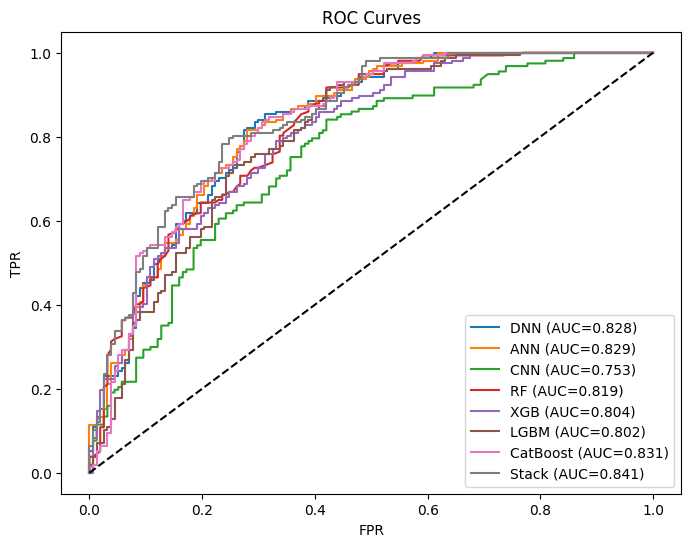

In [19]:
# Cell 17 - ROC curves
plt.figure(figsize=(8,6))
from sklearn.metrics import roc_curve, auc
models_probs = {
    'DNN': y_prob_dnn,
    'ANN': y_prob_ann,
    'CNN': y_prob_cnn,
    'RF': y_prob_rf,
    'XGB': y_prob_xgb,
    'LGBM': y_prob_lgb,
    'CatBoost': y_prob_cat,
    'Stack': y_prob_stack
}
for name, probs in models_probs.items():
    if probs is None:
        continue
    try:
        fpr, tpr, _ = roc_curve(y_test, probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
    except Exception as e:
        pass
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curves'); plt.legend(); plt.show()

In [20]:
# Cell 18 - Save encoders/scalers summary (files in saved_models)
print('Saved artifacts in', OUTPUT_DIR)
os.listdir(OUTPUT_DIR)[:50]

Saved artifacts in ./saved_models


['ann_model.h5',
 'catboost_model.cbm',
 'cnn_model.h5',
 'dnn_model.h5',
 'iterative_imputer.joblib',
 'le_ever_married.joblib',
 'le_gender.joblib',
 'le_Residence_type.joblib',
 'le_smoking_status.joblib',
 'le_work_type.joblib',
 'lgb_model.joblib',
 'minmax_scaler.joblib',
 'random_undersampler.joblib',
 'rf_model.joblib',
 'stacking_ensemble.joblib',
 'xgb_model.joblib']

## Notes & Next steps

- If the surgical pretraining dataset is available and has the same feature count and meaning, the Transfer Learning cell can be used; otherwise adapt features or use representation-transfer approaches.
- Hyperparameters used are reasonable defaults; the paper may list different exact values — if you want those exact numbers paste the table and I'll adapt.
- You can now download this notebook file and run it in your environment. Models and encoders are saved to `./saved_models`.

Enjoy!

In [21]:
# Cell - Load model(s) and make predictions on new data
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf

# Paths
OUTPUT_DIR = "./saved_models"

# Load preprocessing artifacts
scaler = joblib.load(os.path.join(OUTPUT_DIR, "minmax_scaler.joblib"))
rus = joblib.load(os.path.join(OUTPUT_DIR, "random_undersampler.joblib"))
num_imputer = joblib.load(os.path.join(OUTPUT_DIR, "iterative_imputer.joblib"))

# Load encoders
encoders = {}
for f in os.listdir(OUTPUT_DIR):
    if f.startswith("le_") and f.endswith(".joblib"):
        colname = f.replace("le_", "").replace(".joblib", "")
        encoders[colname] = joblib.load(os.path.join(OUTPUT_DIR, f))

print(f"Loaded {len(encoders)} encoders, scaler, and imputer.")

# Example: load DNN model
dnn = tf.keras.models.load_model(os.path.join(OUTPUT_DIR, "dnn_model.h5"))

# Example test data (replace with real new input)
# Make sure the column order matches training features exactly
# Suppose original dataset features were like this:
feature_order = ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
                 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']

# Example new record (dictionary form)
sample = {
    'gender': 'Male',
    'age': 45,
    'hypertension': 0,
    'heart_disease': 1,
    'ever_married': 'Yes',
    'work_type': 'Private',
    'Residence_type': 'Urban',
    'avg_glucose_level': 120.5,
    'bmi': 30.1,
    'smoking_status': 'formerly smoked'
}

# Convert to DataFrame
new_df = pd.DataFrame([sample])

# Apply same preprocessing: impute, encode, scale
# Impute numeric
num_cols = [c for c in new_df.columns if new_df[c].dtype != 'object']
if len(num_cols) > 0:
    new_df[num_cols] = num_imputer.transform(new_df[num_cols])

# Encode categorical
for c in encoders:
    if c in new_df.columns:
        le = encoders[c]
        # unseen label handling
        new_df[c] = new_df[c].apply(lambda x: x if x in le.classes_ else le.classes_[0])
        new_df[c] = le.transform(new_df[c].astype(str))

# Scale numeric
if len(num_cols) > 0:
    new_df[num_cols] = scaler.transform(new_df[num_cols])

# Predict
x_new = new_df[feature_order].values
y_prob = dnn.predict(x_new).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("Predicted Probability of Stroke:", y_prob[0])
print("Predicted Class:", "Stroke" if y_pred[0] == 1 else "No Stroke")


Loaded 5 encoders, scaler, and imputer.
Predicted Probability of Stroke: 0.676759
Predicted Class: Stroke
